# Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter 
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Загружаем данные

In [2]:
DATA_DIR = Path.home() / "apartment-price-prediction" / "data" / "modeling"
FILE_DIR = DATA_DIR / "moscow_train.csv"

In [3]:
df = pd.read_csv(FILE_DIR)

# График зависимости цен

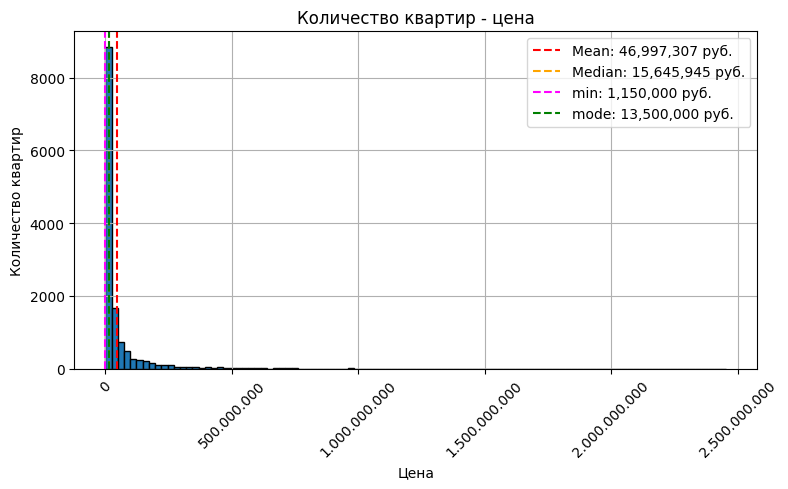

In [4]:
mean = df['Price'].mean()
median = df['Price'].median()
min = df['Price'].min()
mode = df['Price'].mode(dropna=True)[0]


ax = df.hist('Price',bins=100, figsize=(8,5), edgecolor='black').ravel()[0]
plt.title('Количество квартир - цена')
plt.ylabel('Количество квартир')
plt.xlabel("Цена")

plt.xticks(rotation=45)
plt.gca().ticklabel_format(style='plain', axis='x', useOffset=False)

def format_with_dots(x, pos):
    return f"{int(x):,}".replace(",", ".")

ax.xaxis.set_major_formatter(FuncFormatter(format_with_dots))


# for rect in ax.patches:
#     height = rect.get_height()          
#     if height > 0:
#         x_center = rect.get_x() + rect.get_width() / 2
#         y_position = height + 0.5
#         ax.text(x_center, y_position, int(height),
#                 ha='center', va='bottom', fontsize=9)

plt.axvline(x=mean,
           color='red',
           linestyle='--',
           linewidth=1.5,
           label=f'Mean: {mean:,.0f} руб.')

plt.axvline(x=median,
           color='orange',
           linestyle='--',
           linewidth=1.5,
           label=f'Median: {median:,.0f} руб.')

plt.axvline(x=min,
           color='magenta',
           linestyle='--',
           linewidth=1.5,
           label=f'min: {min:,.0f} руб.')

plt.axvline(x=mode,
           color='green',
           linestyle='--',
           linewidth=1.5,
           label=f'mode: {mode:,.0f} руб.')


plt.legend()
plt.tight_layout()
plt.show()

# Анализ минимума, максимума, медианы цен

In [5]:
pd.set_option('display.float_format', lambda x: f'{x:,.0f}'.replace(',', '.'))

df.describe()

,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Price,Price_log
count,13.211,13.237,13.237,13.237,13.237,12.880,12.880,13.237,13.237
mean,13,2,81,43,13,9,16,46.997.307,17
std,7,2,78,43,8,8,11,93.433.198,1
min,0,0,6,2,1,1,1,1.150.000,14
25%,7,1,38,18,9,3,9,9.966.870,16
50%,12,2,60,31,11,7,14,15.645.945,17
75%,17,3,93,50,16,13,20,39.200.000,17
max,60,10,1.117,567,100,82,97,2.455.020.000,22


# График зависимости прологарифмированных цен

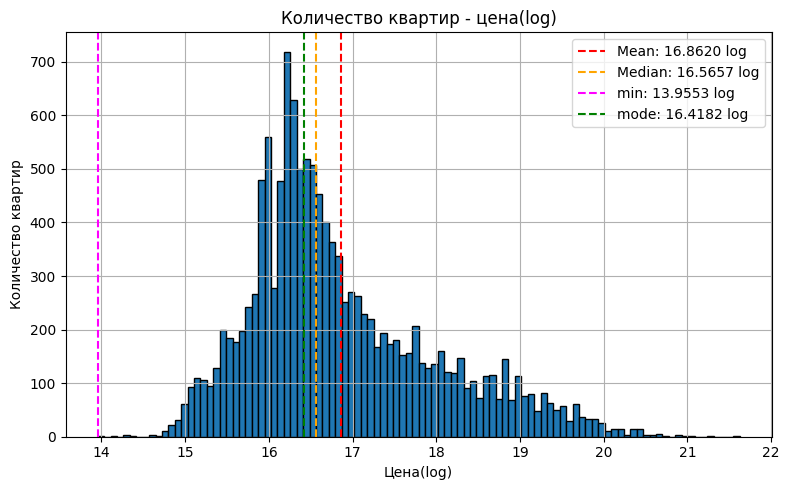

In [6]:
mean = df['Price_log'].mean()
median = df['Price_log'].median()
min = df['Price_log'].min()
mode = df['Price_log'].mode(dropna=True)[0]


ax = df.hist('Price_log', bins=100, figsize=(8,5), edgecolor='black').ravel()[0]
plt.title('Количество квартир - цена(log)')
plt.ylabel('Количество квартир')
plt.xlabel("Цена(log)")

plt.xticks(rotation=0)
plt.gca().ticklabel_format(style='plain', axis='x', useOffset=False)

def format_with_dots(x, pos):
    return f"{int(x):,}".replace(",", ".")

ax.xaxis.set_major_formatter(FuncFormatter(format_with_dots))


# for rect in ax.patches:
#     height = rect.get_height()          
#     if height > 0:
#         x_center = rect.get_x() + rect.get_width() / 2
#         y_position = height + 0.5
#         ax.text(x_center, y_position, int(height),
#                 ha='center', va='bottom', fontsize=9)

plt.axvline(x=mean,
           color='red',
           linestyle='--',
           linewidth=1.5,
           label=f'Mean: {mean:,.4f} log')

plt.axvline(x=median,
           color='orange',
           linestyle='--',
           linewidth=1.5,
           label=f'Median: {median:,.4f} log')

plt.axvline(x=min,
           color='magenta',
           linestyle='--',
           linewidth=1.5,
           label=f'min: {min:,.4f} log')

plt.axvline(x=mode,
           color='green',
           linestyle='--',
           linewidth=1.5,
           label=f'mode: {mode:,.4f} log')


plt.legend()
plt.tight_layout()
plt.show()

# Обучение OLS

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                 2.040e+04
Date:                Mon, 08 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:01:35   Log-Likelihood:            -2.5554e+05
No. Observations:               13237   AIC:                         5.111e+05
Df Residuals:                   13235   BIC:                         5.111e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -2.887e+07   7.36e+05    -39.226      0.0

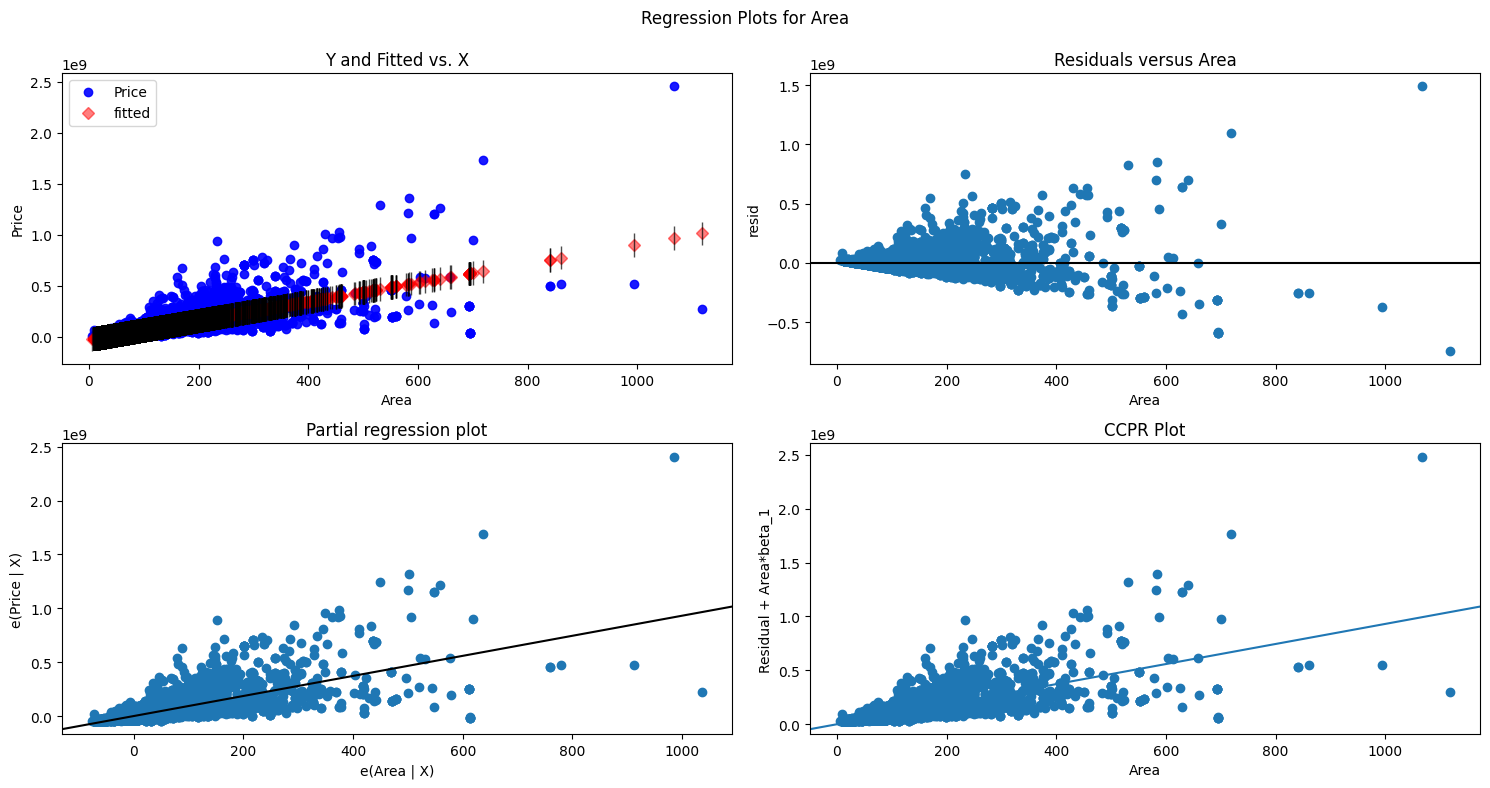

In [7]:
f = 'Price~Area'

model = ols(formula=f, data=df).fit()

fig = plt.figure(figsize =(15,8))
fig = sm.graphics.plot_regress_exog(model, 'Area', fig=fig)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                 2.040e+04
Date:                Mon, 08 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:01:37   Log-Likelihood:            -2.5554e+05
No. Observations:               13237   AIC:                         5.111e+05
Df Residuals:                   13235   BIC:                         5.111e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -2.887e+07   7.36e+05    -39.226      0.0

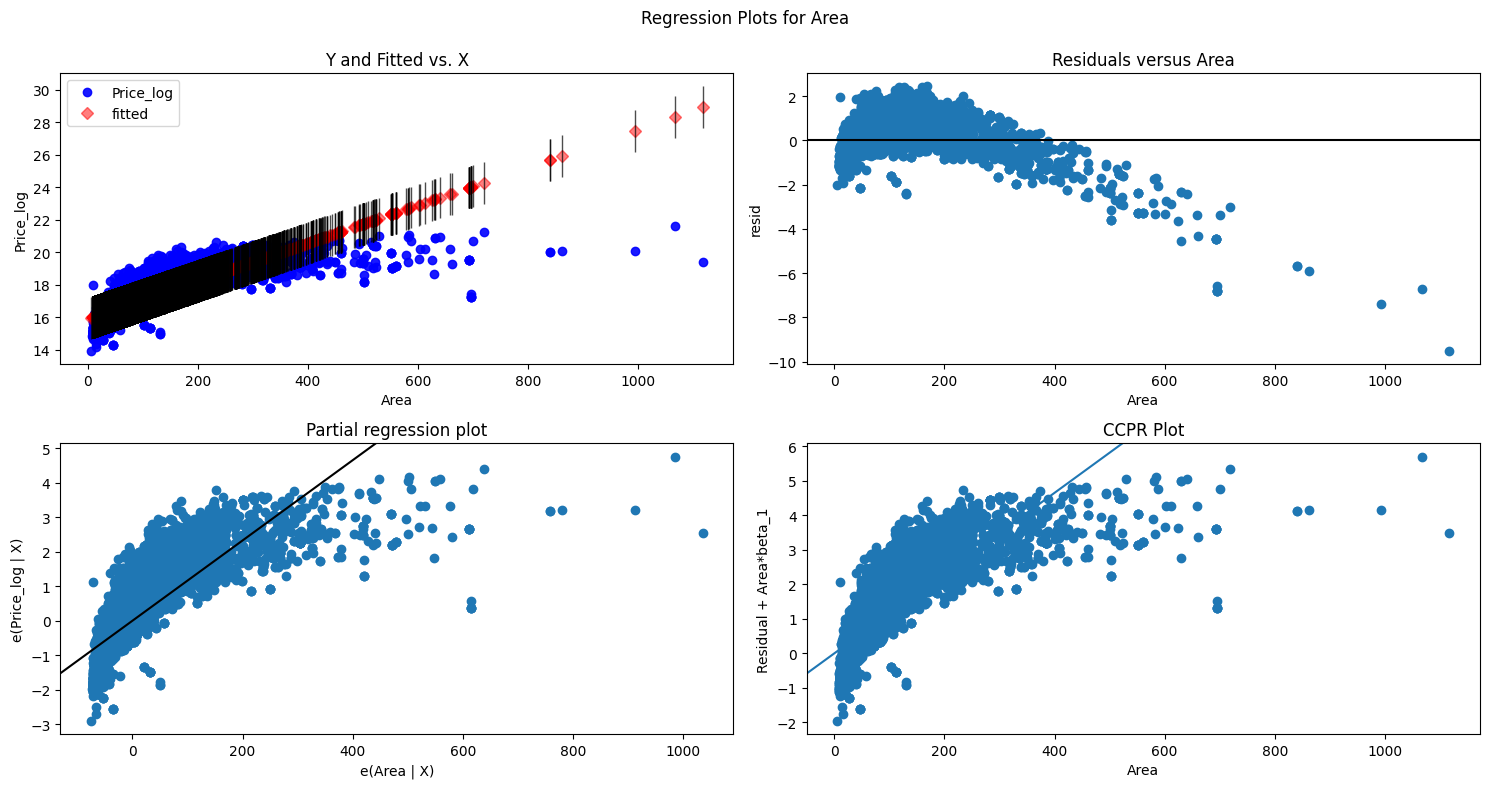

In [8]:
f = 'Price_log~Area'

model_log = ols(formula=f, data=df).fit()



fig = plt.figure(figsize =(15,8))

fig = sm.graphics.plot_regress_exog(model_log,'Area', fig=fig)

print(model.summary())
